# Tuleva Savers Analysis — Members vs Non-Members

Comparison of Tuleva members and non-member savers across AUM, withdrawals, savings behavior, demographics, and personas.

Data source: Metabase question 2324 (all savers)

In [1]:
import sys, os
from pathlib import Path
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import numpy as np

# Load env and project paths
project_root = Path.cwd().parents[1]
load_dotenv(project_root / '.env')
sys.path.insert(0, str(project_root / 'common' / 'scripts'))

from metabase_client import MetabaseClient
from generate_charts import setup_plot_style, TULEVA_BLUE, TULEVA_NAVY, TULEVA_MID_BLUE

setup_plot_style()

COLORS = [TULEVA_NAVY, TULEVA_BLUE, TULEVA_MID_BLUE, '#B0D4F1']
POSITIVE_COLOR = '#51c26c'
NEGATIVE_COLOR = '#FF4800'

# Member vs non-member colors
MEMBER_COLOR = TULEVA_NAVY
NONMEMBER_COLOR = '#B0D4F1'
MEMBER_COLORS = [TULEVA_NAVY, TULEVA_BLUE, TULEVA_MID_BLUE]
NONMEMBER_COLORS = ['#8FBDDB', '#B0D4F1', '#D0E6F5']

client = MetabaseClient()
print(f'Connected to {client.base_url}')

Connected to https://metabase.tuleva.ee


In [2]:
# Fetch ALL savers (members + non-members) from card 2324
raw = client.execute_card(2324)
df = pd.DataFrame(raw)

# Source column: Member vs Non-member
df['Source'] = np.where(df['Member Active'], 'Member', 'Non-member')

# Derived columns
df['Total AUM'] = df['Tuk75 Current Aum'] + df['Tuk00 Current Aum'] + df['Third Pillar Current Aum']
df['II Pillar AUM'] = df['Tuk75 Current Aum'] + df['Tuk00 Current Aum']
df['Has II Pillar'] = df['Active In Tuk75'] | df['Active In Tuk00']
df['Has III Pillar'] = df['Third Pillar Current Aum'] > 0
df['Has Both Pillars'] = df['Has II Pillar'] & df['Has III Pillar']

# Age bins
df['Age Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 45, 55, 65, 100],
                         labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

# Salary bins
df['Salary Group'] = pd.cut(df['Latest Salary'], bins=[0, 1000, 1500, 2000, 3000, 5000, 100000],
                            labels=['<1000', '1000-1500', '1500-2000', '2000-3000', '3000-5000', '5000+'])

print(f'Total savers: {len(df):,}')
print(f'  Members:     {(df["Source"] == "Member").sum():,}')
print(f'  Non-members: {(df["Source"] == "Non-member").sum():,}')
print(f'\nTotal AUM: {df["Total AUM"].sum() / 1e6:.1f} M EUR')
print(f'  Members:     {df.loc[df["Source"] == "Member", "Total AUM"].sum() / 1e6:.1f} M EUR')
print(f'  Non-members: {df.loc[df["Source"] == "Non-member", "Total AUM"].sum() / 1e6:.1f} M EUR')
df.head(3)

Total savers: 96,569
  Members:     9,573
  Non-members: 86,996

Total AUM: 1442.1 M EUR
  Members:     471.8 M EUR
  Non-members: 970.3 M EUR


,Member Active,Age,Early Withdrawal Date,Active In Tuk00,Last Transfer Out Date,Latest Salary,Third Pillar Max Reporting Date,Third Pillar Last 12m Contributions Sum,Current Rate,Active In Tuk75,...,Second Pillar End Date,Gender,Source,Total AUM,II Pillar AUM,Has II Pillar,Has III Pillar,Has Both Pillars,Age Group,Salary Group
0,None,78.0,None,False,None,NaN,2026-03-01,500.0,2.0,False,...,2009-12-31,F,Non-member,1968,0,False,True,False,65+,NaN
1,None,76.0,None,False,None,NaN,2026-03-01,400.0,2.0,False,...,2010-12-31,F,Non-member,1274,0,False,True,False,65+,NaN
2,None,76.0,None,False,None,NaN,2026-03-01,150.0,2.0,False,...,2011-12-31,F,Non-member,154,0,False,True,False,65+,NaN


## 1. Data Overview

In [3]:
# Key stats by Source
for source in ['Member', 'Non-member']:
    sub = df[df['Source'] == source]
    print(f'--- {source} ({len(sub):,} savers) ---')
    print(f'  Total AUM:        {sub["Total AUM"].sum() / 1e6:.1f} M EUR')
    print(f'  Mean AUM:         {sub["Total AUM"].mean():,.0f} EUR')
    print(f'  II pillar savers: {sub["Has II Pillar"].sum():,} ({sub["Has II Pillar"].mean():.0%})')
    print(f'  III pillar:       {sub["Has III Pillar"].sum():,} ({sub["Has III Pillar"].mean():.0%})')
    print(f'  Both pillars:     {sub["Has Both Pillars"].sum():,} ({sub["Has Both Pillars"].mean():.0%})')
    print(f'  Gender:           {sub["Gender"].value_counts().to_dict()}')
    print()

--- Member (9,573 savers) ---
  Total AUM:        471.8 M EUR
  Mean AUM:         49,283 EUR
  II pillar savers: 8,015 (84%)
  III pillar:       7,986 (83%)
  Both pillars:     6,947 (73%)
  Gender:           {'M': 5731, 'F': 3842}

--- Non-member (86,996 savers) ---
  Total AUM:        970.3 M EUR
  Mean AUM:         11,154 EUR
  II pillar savers: 36,488 (42%)
  III pillar:       63,343 (73%)
  Both pillars:     21,747 (25%)
  Gender:           {'F': 47725, 'M': 39271}



In [4]:
df.groupby('Source').describe().T.round(2)

Source                  Member  Non-member
Age           count    9573.00    86996.00
              mean       44.16       36.49
              std         9.11       12.34
              min        18.00        0.00
              25%        37.00       29.00
...                        ...         ...
II Pillar AUM min         0.00        0.00
              25%       600.00        0.00
              50%     26176.00        0.00
              75%     47883.00     8089.25
              max    522156.00   249020.00

[72 rows x 2 columns]

## 2. AUM Distribution

In [5]:
# AUM breakdown by pillar and Source
rows = []
for source in ['Member', 'Non-member', 'Total']:
    sub = df if source == 'Total' else df[df['Source'] == source]
    for fund, col in [('Tuk75 (II growth)', 'Tuk75 Current Aum'),
                      ('Tuk00 (II conservative)', 'Tuk00 Current Aum'),
                      ('III Pillar', 'Third Pillar Current Aum'),
                      ('Total', 'Total AUM')]:
        pos = sub.loc[sub[col] > 0, col]
        rows.append({
            'Source': source,
            'Fund': fund,
            'Total AUM (M EUR)': sub[col].sum() / 1e6,
            'Savers with AUM > 0': (sub[col] > 0).sum(),
            'Mean AUM (EUR)': pos.mean() if len(pos) else 0,
            'Median AUM (EUR)': pos.median() if len(pos) else 0,
        })

aum_summary = pd.DataFrame(rows)
aum_summary.style.format({
    'Total AUM (M EUR)': '{:.1f}',
    'Savers with AUM > 0': '{:,.0f}',
    'Mean AUM (EUR)': '{:,.0f}',
    'Median AUM (EUR)': '{:,.0f}',
})

,Source,Fund,Total AUM (M EUR),Savers with AUM > 0,Mean AUM (EUR),Median AUM (EUR)
0,Member,Tuk75 (II growth),321.5,"7,215","44,559","35,785"
1,Member,Tuk00 (II conservative),2.3,131,"17,417","7,978"
2,Member,III Pillar,148.0,"7,986","18,534","11,662"
3,Member,Total,471.8,"8,724","54,079","43,214"
4,Non-member,Tuk75 (II growth),625.5,"32,391","19,312","14,559"
5,Non-member,Tuk00 (II conservative),9.4,"1,878","4,992",992
6,Non-member,III Pillar,335.4,"63,343","5,295","1,541"
7,Non-member,Total,970.3,"76,331","12,712","3,792"
8,Total,Tuk75 (II growth),947.0,"39,606","23,911","17,500"
9,Total,Tuk00 (II conservative),11.7,"2,009","5,803","1,242"


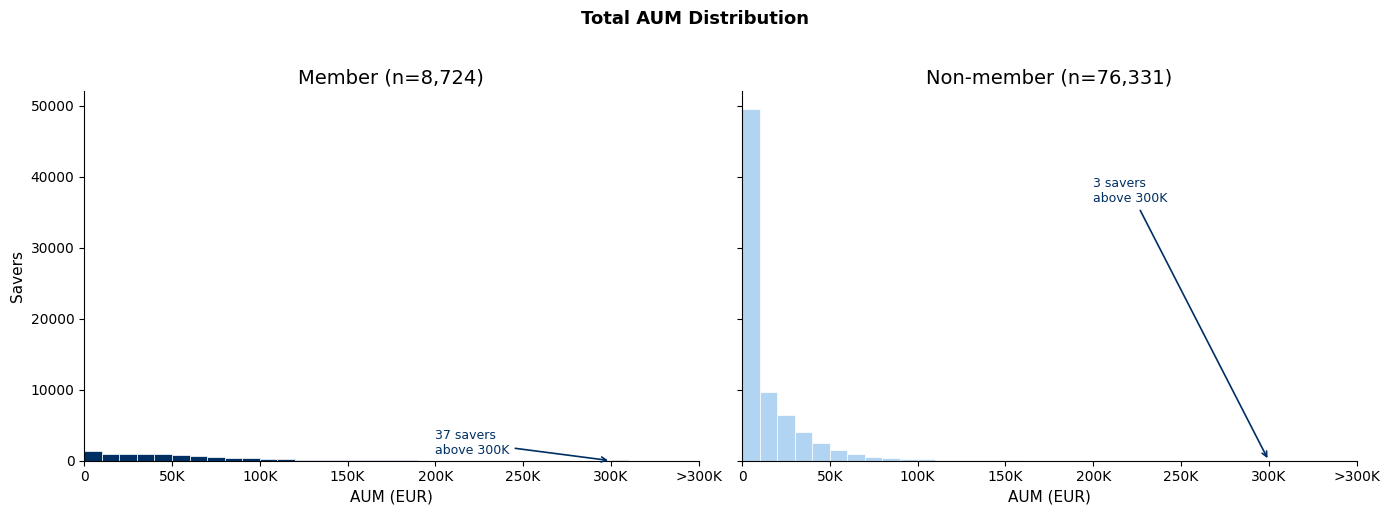

In [6]:
# Total AUM distribution — Members vs Non-members (side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, source, color in zip(axes, ['Member', 'Non-member'], [MEMBER_COLOR, NONMEMBER_COLOR]):
    sub = df[(df['Source'] == source) & (df['Total AUM'] > 0)]
    aum_capped = sub['Total AUM'].clip(upper=300000)
    n_above = (sub['Total AUM'] > 300000).sum()

    ax.hist(aum_capped, bins=range(0, 310001, 10000), color=color, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{source} (n={len(sub):,})')
    ax.set_xlabel('AUM (EUR)')
    ax.set_xlim(0, 310000)
    ax.set_xticks(range(0, 350001, 50000))
    ax.set_xticklabels(['0', '50K', '100K', '150K', '200K', '250K', '300K', '>300K'])
    if n_above > 0:
        ax.annotate(f'{n_above:,} savers\nabove 300K',
                    xy=(300000, 0), xytext=(200000, ax.get_ylim()[1] * 0.7),
                    fontsize=9, color=TULEVA_NAVY,
                    arrowprops=dict(arrowstyle='->', color=TULEVA_NAVY, lw=1.2))

axes[0].set_ylabel('Savers')
fig.suptitle('Total AUM Distribution', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

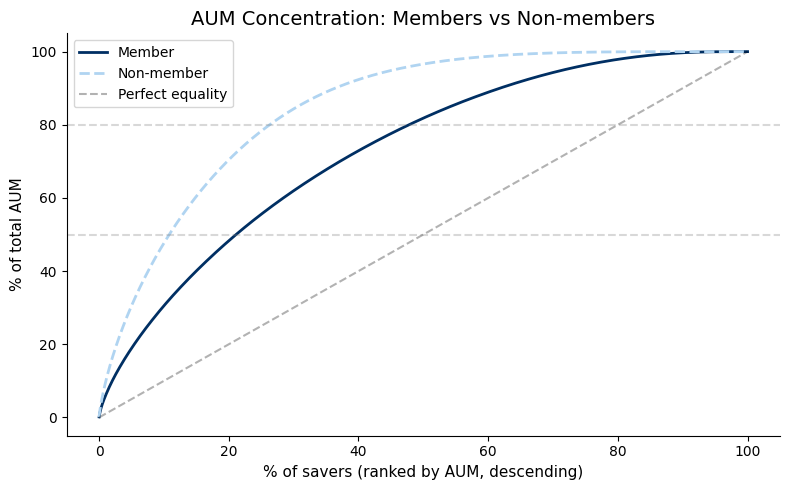

In [7]:
# AUM concentration — Lorenz curve (Members vs Non-members)
fig, ax = plt.subplots(figsize=(8, 5))

for source, color, ls in [('Member', MEMBER_COLOR, '-'), ('Non-member', NONMEMBER_COLOR, '--')]:
    sub = df[(df['Source'] == source) & (df['Total AUM'] > 0)]
    aum_sorted = sub['Total AUM'].sort_values(ascending=False)
    cumulative_share = aum_sorted.cumsum() / aum_sorted.sum()
    member_pct = np.arange(1, len(aum_sorted) + 1) / len(aum_sorted) * 100
    ax.plot(member_pct, cumulative_share * 100, color=color, linewidth=2, linestyle=ls, label=source)

ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, label='Perfect equality')
ax.set_xlabel('% of savers (ranked by AUM, descending)')
ax.set_ylabel('% of total AUM')
ax.set_title('AUM Concentration: Members vs Non-members')
ax.legend()
ax.axhline(y=50, color='grey', linestyle='--', alpha=0.3)
ax.axhline(y=80, color='grey', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

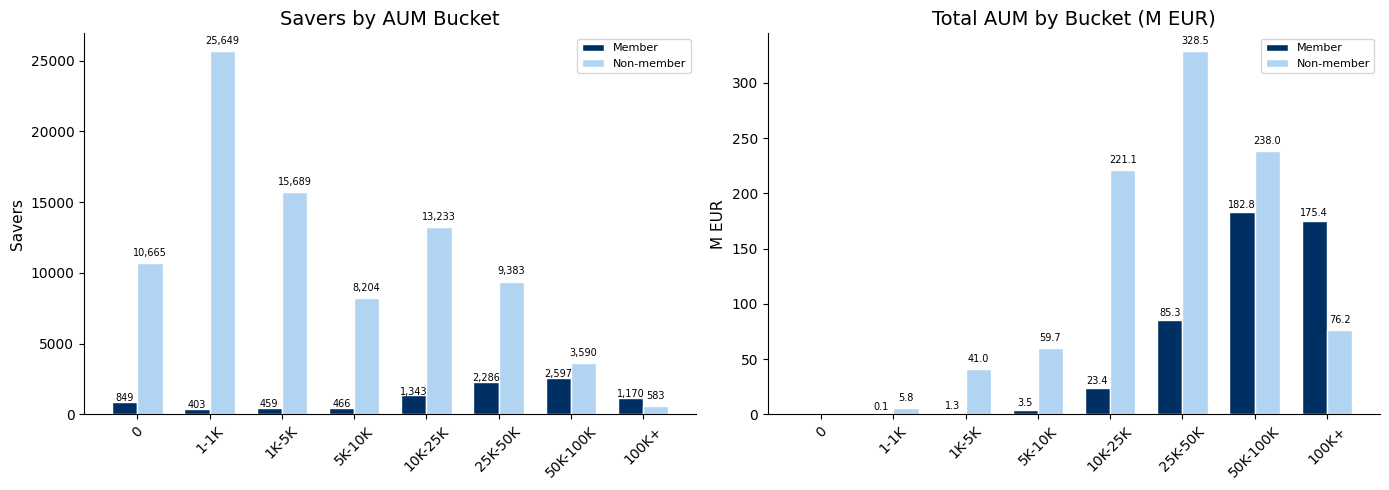

In [8]:
# AUM buckets — Members vs Non-members
bucket_labels = ['0', '1-1K', '1K-5K', '5K-10K', '10K-25K', '25K-50K', '50K-100K', '100K+']
bucket_bins = [-1, 0, 1000, 5000, 10000, 25000, 50000, 100000, float('inf')]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel, fmt_fn in [
    (axes[0], 'count', 'Savers', lambda v: f'{v:,.0f}'),
    (axes[1], 'aum', 'M EUR', lambda v: f'{v:.1f}'),
]:
    x = np.arange(len(bucket_labels))
    w = 0.35
    for offset, source, color in [(-w/2, 'Member', MEMBER_COLOR), (w/2, 'Non-member', NONMEMBER_COLOR)]:
        sub = df[df['Source'] == source]
        buckets = pd.cut(sub['Total AUM'], bins=bucket_bins, labels=bucket_labels)
        if metric == 'count':
            vals = buckets.value_counts().reindex(bucket_labels, fill_value=0).values
        else:
            vals = sub['Total AUM'].groupby(buckets, observed=False).sum().reindex(bucket_labels, fill_value=0).values / 1e6
        bars = ax.bar(x + offset, vals, w, color=color, edgecolor='white', label=source)
        for i, v in enumerate(vals):
            if v > 0:
                ax.text(i + offset, v + max(vals) * 0.02, fmt_fn(v), ha='center', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(bucket_labels, rotation=45)
    ax.set_ylabel(ylabel)
    ax.set_title('Savers by AUM Bucket' if metric == 'count' else 'Total AUM by Bucket (M EUR)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Withdrawal Analysis

In [9]:
# Withdrawal flags
has_early_wd = df['Early Withdrawal Date'].notna()
has_transfer = df['Last Transfer Out Date'].notna()
has_iii_redeemed = df['Third Pillar All Shares Redeemed Date'].notna()
has_ii_ended = df['Second Pillar End Date'].notna()
has_ii_pension_age = has_ii_ended & ~has_early_wd

# II pillar withdrawal type
ii_type = pd.Series('No II withdrawal', index=df.index)
ii_type[has_ii_pension_age] = 'II after pension age'
ii_type[has_transfer] = 'Transfer out'
ii_type[has_early_wd] = 'Early withdrawal'

iii_suffix = np.where(has_iii_redeemed, ' + III redeemed', '')
df['Withdrawal Group'] = ii_type + iii_suffix
df['Withdrawal Group'] = df['Withdrawal Group'].replace({
    'No II withdrawal': 'No withdrawals',
    'No II withdrawal + III redeemed': 'III redeemed only',
})

wd_order = [
    'Early withdrawal + III redeemed',
    'Early withdrawal',
    'Transfer out + III redeemed',
    'Transfer out',
    'II after pension age',
    'III redeemed only',
    'No withdrawals',
]

# Summary by Source
wd_by_source = df.groupby(['Withdrawal Group', 'Source']).size().unstack(fill_value=0).reindex(wd_order, fill_value=0)
wd_by_source['Total'] = wd_by_source.sum(axis=1)
for col in ['Member', 'Non-member', 'Total']:
    wd_by_source[f'{col} %'] = wd_by_source[col] / wd_by_source[col].sum() * 100

display_cols = ['Member', 'Member %', 'Non-member', 'Non-member %', 'Total', 'Total %']
wd_by_source[display_cols].style.format({
    'Member': '{:,}', 'Member %': '{:.1f}%',
    'Non-member': '{:,}', 'Non-member %': '{:.1f}%',
    'Total': '{:,}', 'Total %': '{:.1f}%',
})

Source,Member,Member %,Non-member,Non-member %,Total,Total %
Withdrawal Group,,,,,,
Early withdrawal + III redeemed,120,1.3%,709,0.8%,829,0.9%
Early withdrawal,"1,046",10.9%,"12,749",14.7%,"13,795",14.3%
Transfer out + III redeemed,39,0.4%,271,0.3%,310,0.3%
Transfer out,704,7.4%,"8,298",9.5%,"9,002",9.3%
II after pension age,60,0.6%,351,0.4%,411,0.4%
III redeemed only,110,1.1%,"1,764",2.0%,"1,874",1.9%
No withdrawals,"7,494",78.3%,"62,844",72.2%,"70,338",72.8%


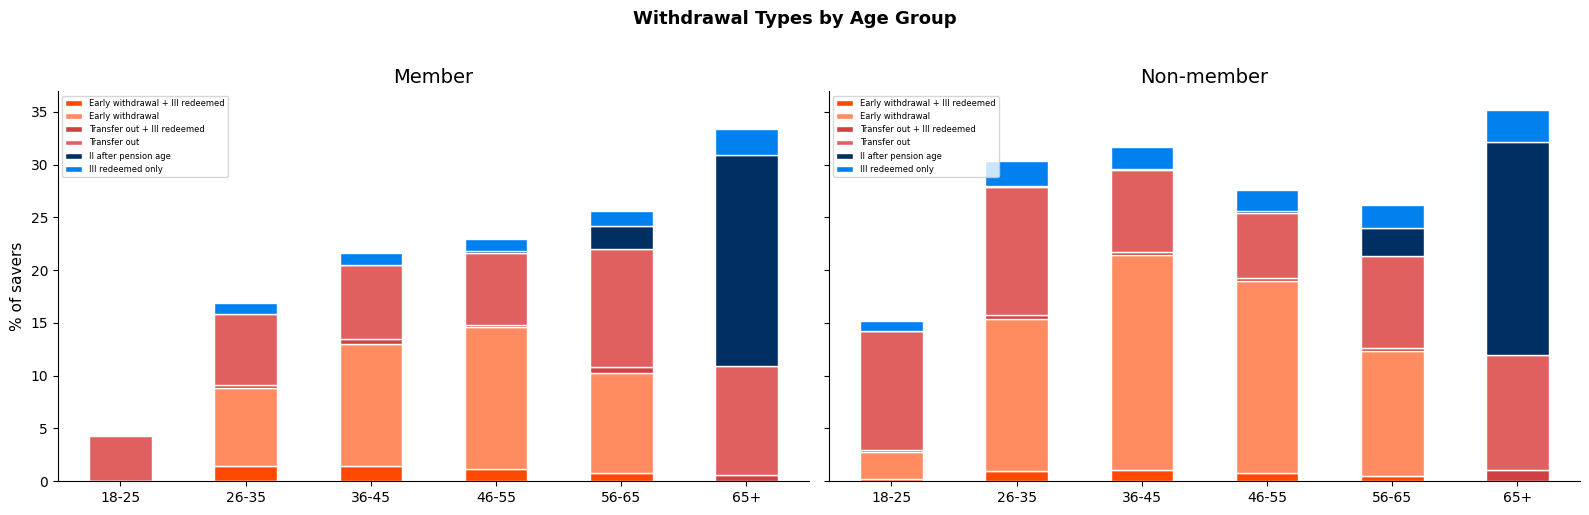

In [10]:
# Withdrawal groups by age — Members vs Non-members
wd_dummies = pd.get_dummies(df['Withdrawal Group'])
wd_cols_chart = [c for c in wd_order if c != 'No withdrawals']
colors_wd = [NEGATIVE_COLOR, '#FF8C60', '#D04040', '#E06060', TULEVA_NAVY, TULEVA_MID_BLUE]

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, source in zip(axes, ['Member', 'Non-member']):
    sub = df[df['Source'] == source]
    sub_wd = sub.join(wd_dummies.loc[sub.index])
    wd_by_age = sub_wd.groupby('Age Group', observed=True)[wd_cols_chart].mean() * 100
    wd_by_age.plot(kind='bar', stacked=True, ax=ax, color=colors_wd[:len(wd_cols_chart)], edgecolor='white')
    ax.set_title(f'{source}')
    ax.set_ylabel('% of savers')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=6, loc='upper left')

fig.suptitle('Withdrawal Types by Age Group', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Savings Behavior

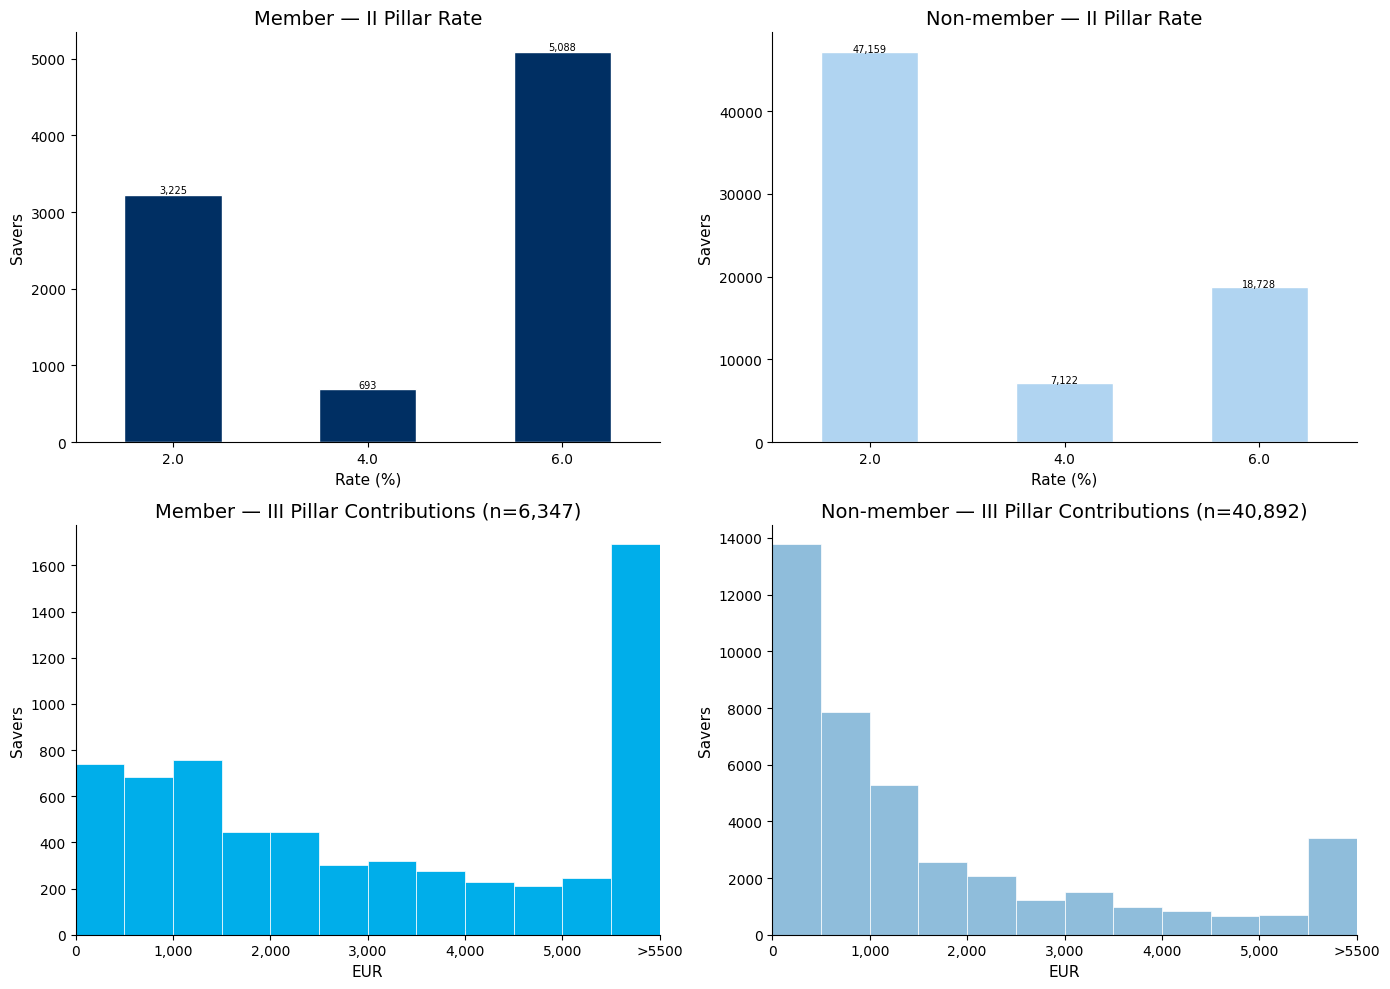

In [11]:
# II Pillar rate + III contributions — Members vs Non-members
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col_idx, (source, color_bar, color_hist) in enumerate([
    ('Member', MEMBER_COLOR, TULEVA_BLUE),
    ('Non-member', NONMEMBER_COLOR, '#8FBDDB'),
]):
    sub = df[df['Source'] == source]
    rates = sub.loc[sub['Current Rate'].notna(), 'Current Rate']
    rate_counts = rates.value_counts().sort_index()

    ax = axes[0, col_idx]
    rate_counts.plot(kind='bar', ax=ax, color=color_bar, edgecolor='white')
    ax.set_title(f'{source} — II Pillar Rate')
    ax.set_xlabel('Rate (%)')
    ax.set_ylabel('Savers')
    ax.tick_params(axis='x', rotation=0)
    for i, (rate, count) in enumerate(rate_counts.items()):
        ax.text(i, count + 20, f'{count:,}', ha='center', fontsize=7)

    iii_contrib = sub.loc[sub['Third Pillar Last 12m Contributions Sum'].notna() &
                          (sub['Third Pillar Last 12m Contributions Sum'] > 0),
                          'Third Pillar Last 12m Contributions Sum']
    iii_capped = iii_contrib.clip(upper=5500)

    ax = axes[1, col_idx]
    ax.hist(iii_capped, bins=range(0, 6001, 500), color=color_hist, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{source} — III Pillar Contributions (n={len(iii_contrib):,})')
    ax.set_xlabel('EUR')
    ax.set_ylabel('Savers')
    ax.set_xlim(0, 6000)
    ticks = list(range(0, 6001, 1000))
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{t:,}' if t < 5500 else '>5500' for t in ticks])

plt.tight_layout()
plt.show()

In [12]:
# Combined savings behavior by Source
iii_c = df['Third Pillar Last 12m Contributions Sum'].fillna(0)
rate_c = df['Current Rate'].fillna(0)

def assign_savings_group(r, iii_val):
    r6 = r >= 6
    if r6 and iii_val >= 5500:
        return 'II 6% + III 5500+'
    if r6 and iii_val >= 1500:
        return 'II 6% + III 1500-5500'
    if r6:
        return 'II 6% + III <1500'
    if iii_val >= 5500:
        return 'II <6% + III 5500+'
    if iii_val >= 1500:
        return 'II <6% + III 1500-5500'
    return 'Others'

df['Savings Group'] = [assign_savings_group(r, i) for r, i in zip(rate_c, iii_c)]

savings_order = [
    'II 6% + III 5500+',
    'II 6% + III 1500-5500',
    'II 6% + III <1500',
    'II <6% + III 5500+',
    'II <6% + III 1500-5500',
    'Others',
]

rows = []
for source in ['Member', 'Non-member']:
    sub_src = df[df['Source'] == source]
    for g in savings_order:
        sub = sub_src[sub_src['Savings Group'] == g]
        sal = sub['Latest Salary'].dropna()
        iii_pos = sub.loc[sub['Third Pillar Last 12m Contributions Sum'] > 0, 'Third Pillar Last 12m Contributions Sum']
        rows.append({
            'Source': source,
            'Group': g,
            'Savers': len(sub),
            '% of Source': len(sub) / len(sub_src) * 100,
            'Mean AUM (EUR)': sub['Total AUM'].mean() if len(sub) else 0,
            'Median Salary': sal.median() if len(sal) else 0,
            'Mean III Contrib': iii_pos.mean() if len(iii_pos) else 0,
        })

savings_tbl = pd.DataFrame(rows)
savings_tbl.style.format({
    'Savers': '{:,}',
    '% of Source': '{:.1f}%',
    'Mean AUM (EUR)': '{:,.0f}',
    'Median Salary': '{:,.0f}',
    'Mean III Contrib': '{:,.0f}',
}).hide(axis='index')

Source,Group,Savers,% of Source,Mean AUM (EUR),Median Salary,Mean III Contrib
Member,II 6% + III 5500+,"1,370",14.3%,"99,337","5,025","6,397"
Member,II 6% + III 1500-5500,"1,643",17.2%,"61,956","3,000","3,226"
Member,II 6% + III <1500,"2,075",21.7%,"43,214","2,655",755
Member,II <6% + III 5500+,321,3.4%,"80,092","5,147","6,589"
Member,II <6% + III 1500-5500,833,8.7%,"50,662","3,530","3,005"
Member,Others,"3,331",34.8%,"22,912","2,497",680
Non-member,II 6% + III 5500+,"1,912",2.2%,"51,262","4,409","6,357"
Non-member,II 6% + III 1500-5500,"4,548",5.2%,"28,179","2,643","3,041"
Non-member,II 6% + III <1500,"12,268",14.1%,"15,027","2,099",614
Non-member,II <6% + III 5500+,"1,497",1.7%,"39,666","4,482","6,523"


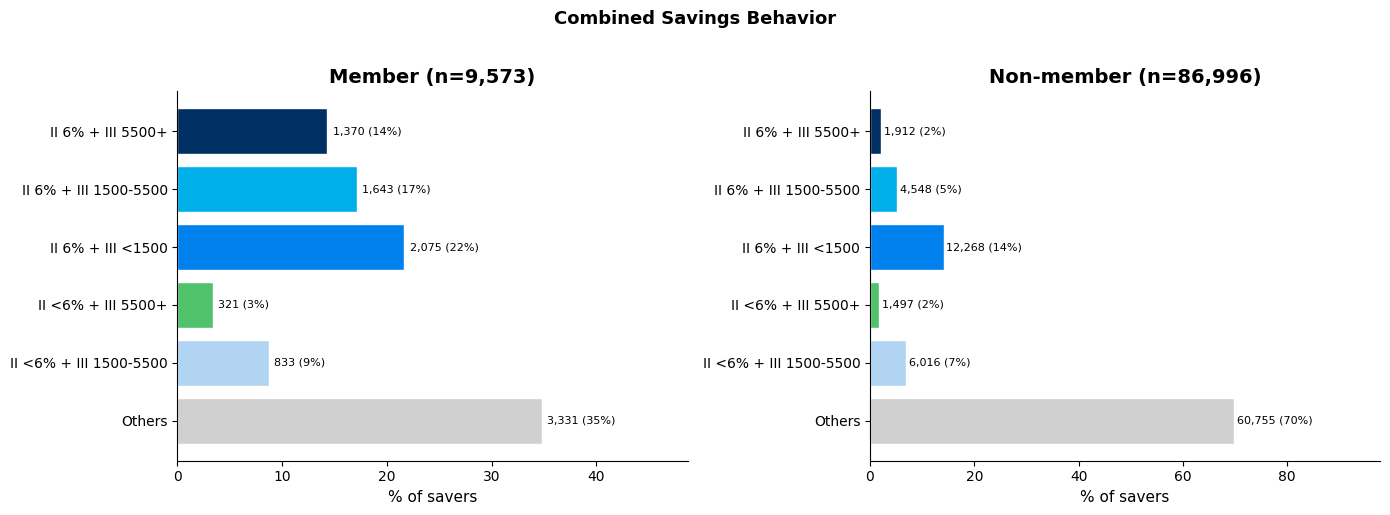

In [13]:
# Combined savings behavior — visual comparison
sg_colors = [TULEVA_NAVY, TULEVA_BLUE, TULEVA_MID_BLUE, '#51c26c', '#B0D4F1', '#D0D0D0']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, source in zip(axes, ['Member', 'Non-member']):
    sub = df[df['Source'] == source]
    counts = sub['Savings Group'].value_counts().reindex(savings_order, fill_value=0)
    pcts = counts / len(sub) * 100
    ax.barh(savings_order[::-1], pcts.values[::-1], color=sg_colors[::-1], edgecolor='white')
    ax.set_title(f'{source} (n={len(sub):,})', fontweight='bold')
    ax.set_xlabel('% of savers')
    for i, (cnt, pct) in enumerate(zip(counts.values[::-1], pcts.values[::-1])):
        ax.text(pct + 0.5, i, f'{cnt:,} ({pct:.0f}%)', va='center', fontsize=8)
    ax.set_xlim(0, pcts.max() * 1.4)

fig.suptitle('Combined Savings Behavior', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 5. Demographics

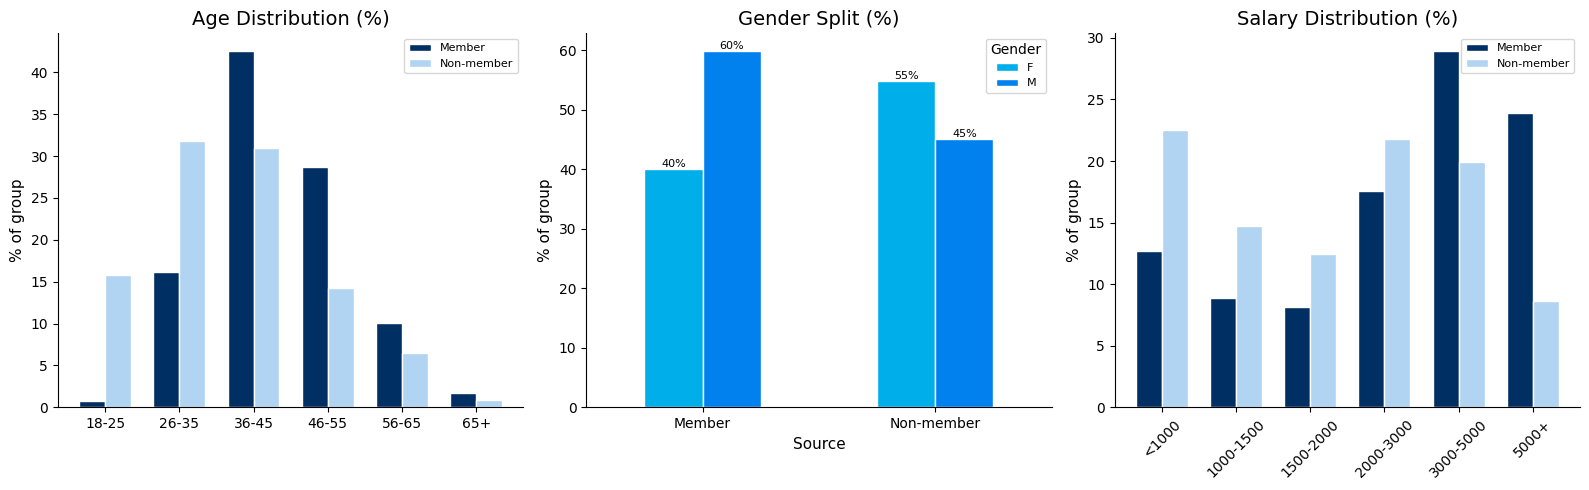

In [14]:
# Age, gender, salary distributions — Members vs Non-members
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution
x = np.arange(len(df['Age Group'].cat.categories))
w = 0.35
for offset, source, color in [(-w/2, 'Member', MEMBER_COLOR), (w/2, 'Non-member', NONMEMBER_COLOR)]:
    sub = df[df['Source'] == source]
    counts = sub['Age Group'].value_counts().sort_index()
    pcts = counts / len(sub) * 100
    axes[0].bar(x + offset, pcts, w, color=color, edgecolor='white', label=source)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df['Age Group'].cat.categories)
axes[0].set_title('Age Distribution (%)')
axes[0].set_ylabel('% of group')
axes[0].legend(fontsize=8)

# Gender split (% within each source)
gender_data = df.groupby(['Source', 'Gender']).size().unstack(fill_value=0)
gender_pct = gender_data.div(gender_data.sum(axis=1), axis=0) * 100
gender_pct.plot(kind='bar', ax=axes[1], color=[TULEVA_BLUE, TULEVA_MID_BLUE], edgecolor='white')
axes[1].set_title('Gender Split (%)')
axes[1].set_ylabel('% of group')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Gender', fontsize=8)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='{:.0f}%', fontsize=8)

# Salary distribution
for offset, source, color in [(-w/2, 'Member', MEMBER_COLOR), (w/2, 'Non-member', NONMEMBER_COLOR)]:
    sub = df[(df['Source'] == source) & df['Latest Salary'].notna()]
    counts = sub['Salary Group'].value_counts().sort_index()
    pcts = counts / len(sub) * 100
    x_sal = np.arange(len(counts))
    axes[2].bar(x_sal + offset, pcts, w, color=color, edgecolor='white', label=source)
axes[2].set_xticks(x_sal)
axes[2].set_xticklabels(df['Salary Group'].cat.categories, rotation=45)
axes[2].set_title('Salary Distribution (%)')
axes[2].set_ylabel('% of group')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

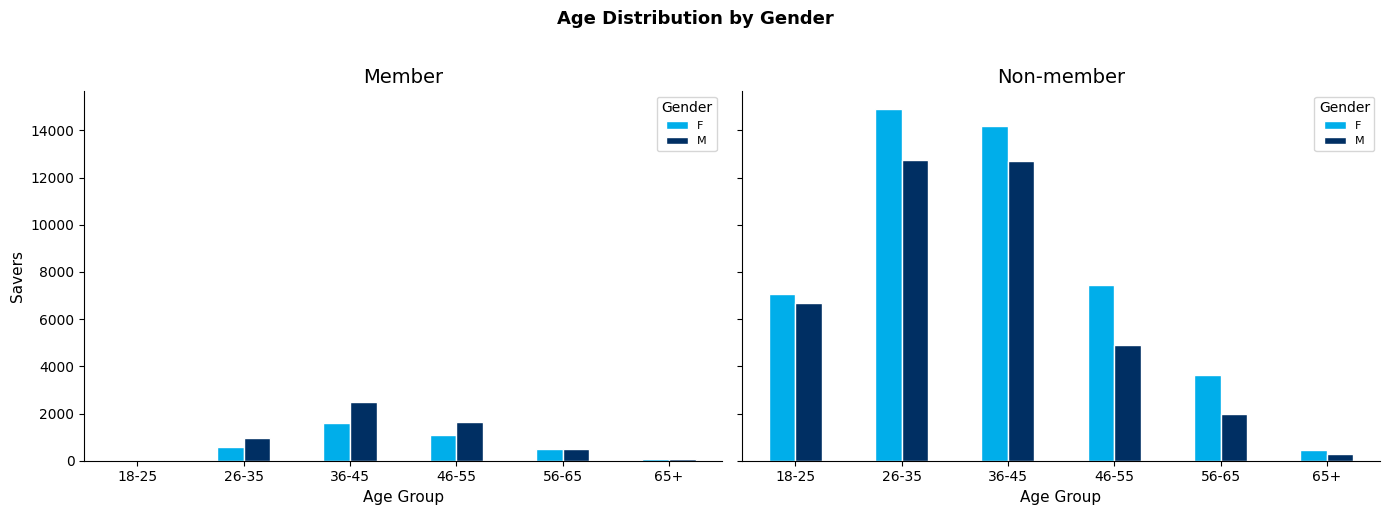

In [15]:
# Age by gender — faceted by Source
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, source in zip(axes, ['Member', 'Non-member']):
    sub = df[df['Source'] == source]
    age_gender = sub.groupby(['Age Group', 'Gender'], observed=True).size().unstack(fill_value=0)
    age_gender.plot(kind='bar', ax=ax, color=[TULEVA_BLUE, TULEVA_NAVY], edgecolor='white')
    ax.set_title(f'{source}')
    ax.set_ylabel('Savers')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Gender', fontsize=8)

fig.suptitle('Age Distribution by Gender', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6. Cross-tabulations

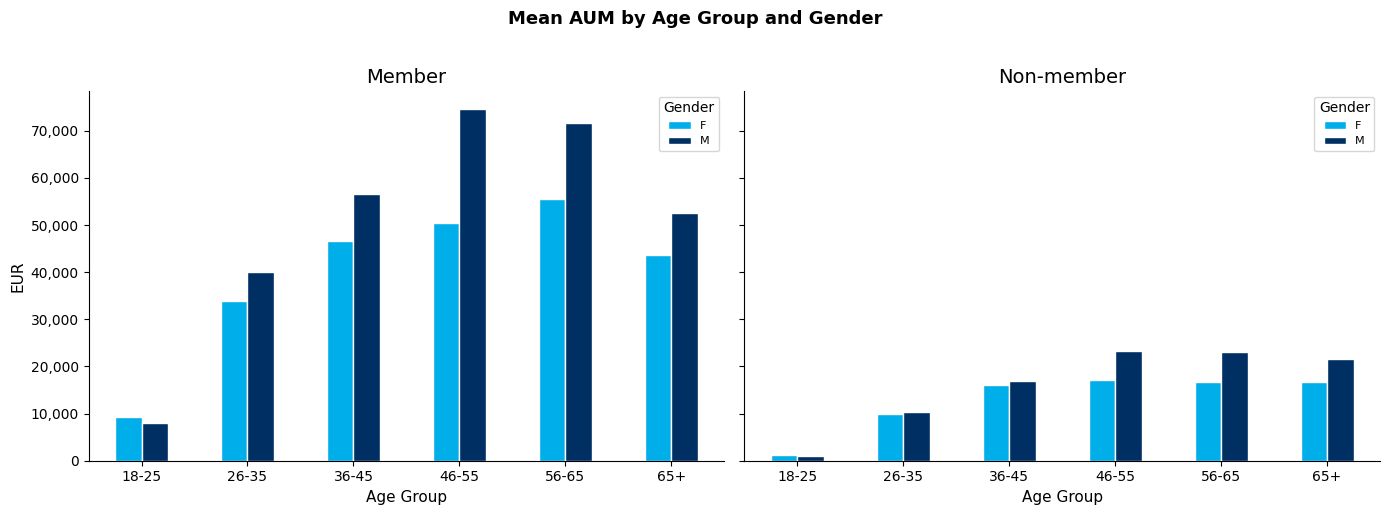

In [16]:
# Mean AUM by age group and gender — faceted by Source
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, source in zip(axes, ['Member', 'Non-member']):
    sub = df[(df['Source'] == source) & (df['Total AUM'] > 0)]
    aum_by_ag = sub.groupby(['Age Group', 'Gender'], observed=True)['Total AUM'].mean().unstack()
    aum_by_ag.plot(kind='bar', ax=ax, color=[TULEVA_BLUE, TULEVA_NAVY], edgecolor='white')
    ax.set_title(f'{source}')
    ax.set_ylabel('EUR')
    ax.tick_params(axis='x', rotation=0)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    ax.legend(title='Gender', fontsize=8)

fig.suptitle('Mean AUM by Age Group and Gender', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

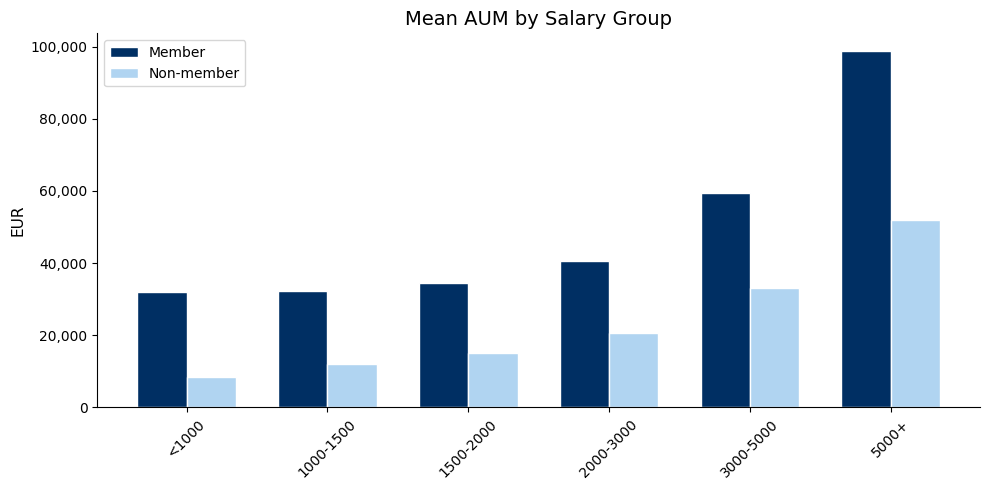

In [17]:
# Mean AUM by salary group — Members vs Non-members
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(df['Salary Group'].cat.categories))
w = 0.35

for offset, source, color in [(-w/2, 'Member', MEMBER_COLOR), (w/2, 'Non-member', NONMEMBER_COLOR)]:
    sub = df[(df['Source'] == source) & (df['Total AUM'] > 0) & df['Latest Salary'].notna()]
    means = sub.groupby('Salary Group', observed=True)['Total AUM'].mean().reindex(df['Salary Group'].cat.categories)
    ax.bar(x + offset, means, w, color=color, edgecolor='white', label=source)

ax.set_xticks(x)
ax.set_xticklabels(df['Salary Group'].cat.categories, rotation=45)
ax.set_title('Mean AUM by Salary Group')
ax.set_ylabel('EUR')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

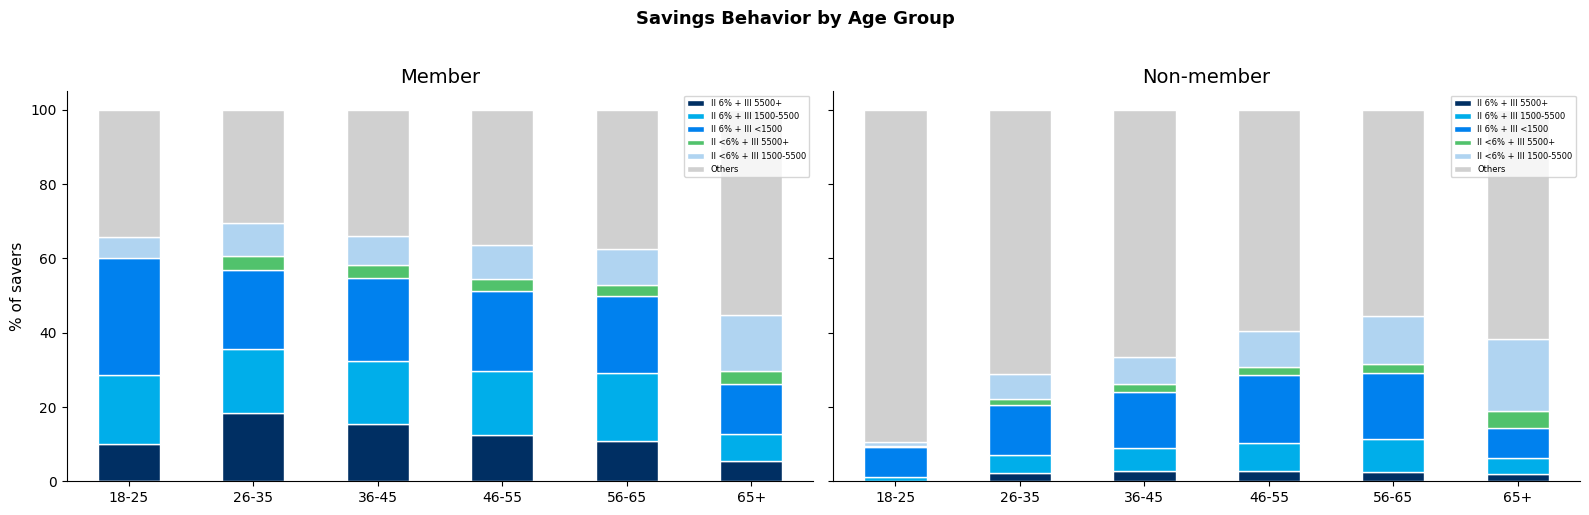

In [18]:
# Savings behavior by age — faceted by Source
sg_dummies = pd.get_dummies(df['Savings Group'])
sg_colors = [TULEVA_NAVY, TULEVA_BLUE, TULEVA_MID_BLUE, '#51c26c', '#B0D4F1', '#D0D0D0']

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, source in zip(axes, ['Member', 'Non-member']):
    sub = df[df['Source'] == source]
    sub_sg = sub.join(sg_dummies.loc[sub.index])
    sg_by_age = sub_sg.groupby('Age Group', observed=True)[savings_order].mean() * 100
    sg_by_age.plot(kind='bar', stacked=True, ax=ax, color=sg_colors, edgecolor='white')
    ax.set_title(f'{source}')
    ax.set_ylabel('% of savers')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(fontsize=6, loc='upper right')

fig.suptitle('Savings Behavior by Age Group', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

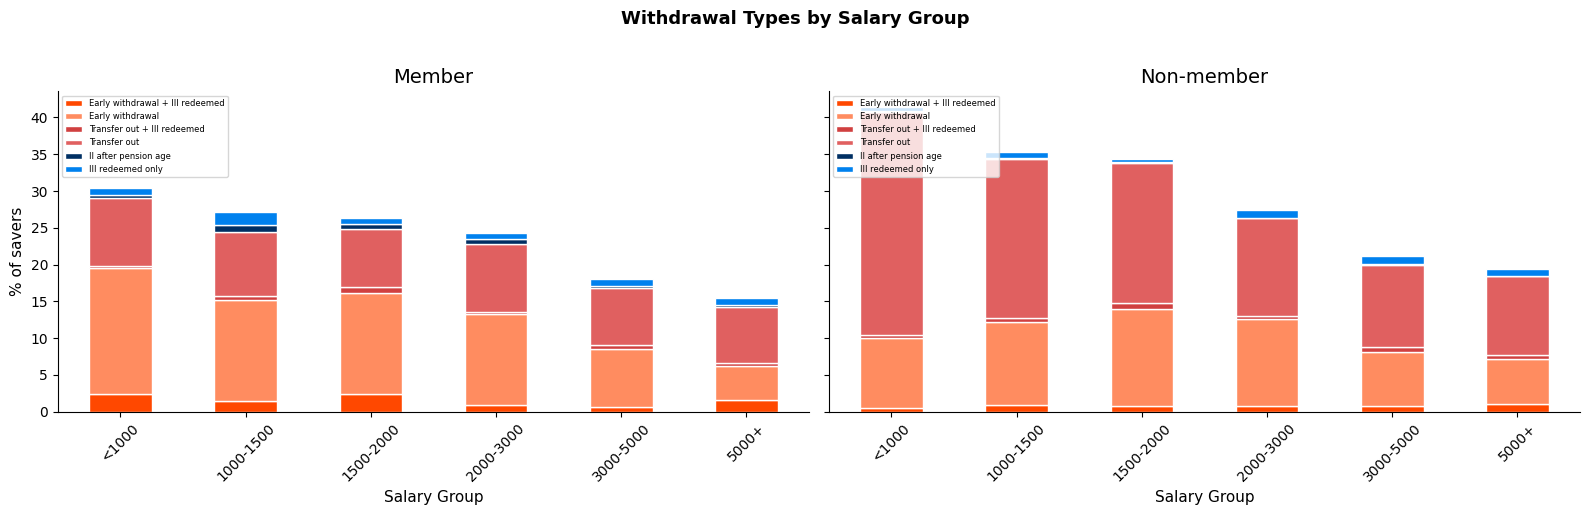

In [19]:
# Withdrawal types by salary — faceted by Source
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, source in zip(axes, ['Member', 'Non-member']):
    sub = df[(df['Source'] == source) & df['Latest Salary'].notna()]
    sub_wd = sub.join(wd_dummies.loc[sub.index])
    wd_by_sal = sub_wd.groupby('Salary Group', observed=True)[wd_cols_chart].mean() * 100
    wd_by_sal.plot(kind='bar', stacked=True, ax=ax, color=colors_wd[:len(wd_cols_chart)], edgecolor='white')
    ax.set_title(f'{source}')
    ax.set_ylabel('% of savers')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=6, loc='upper left')

fig.suptitle('Withdrawal Types by Salary Group', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

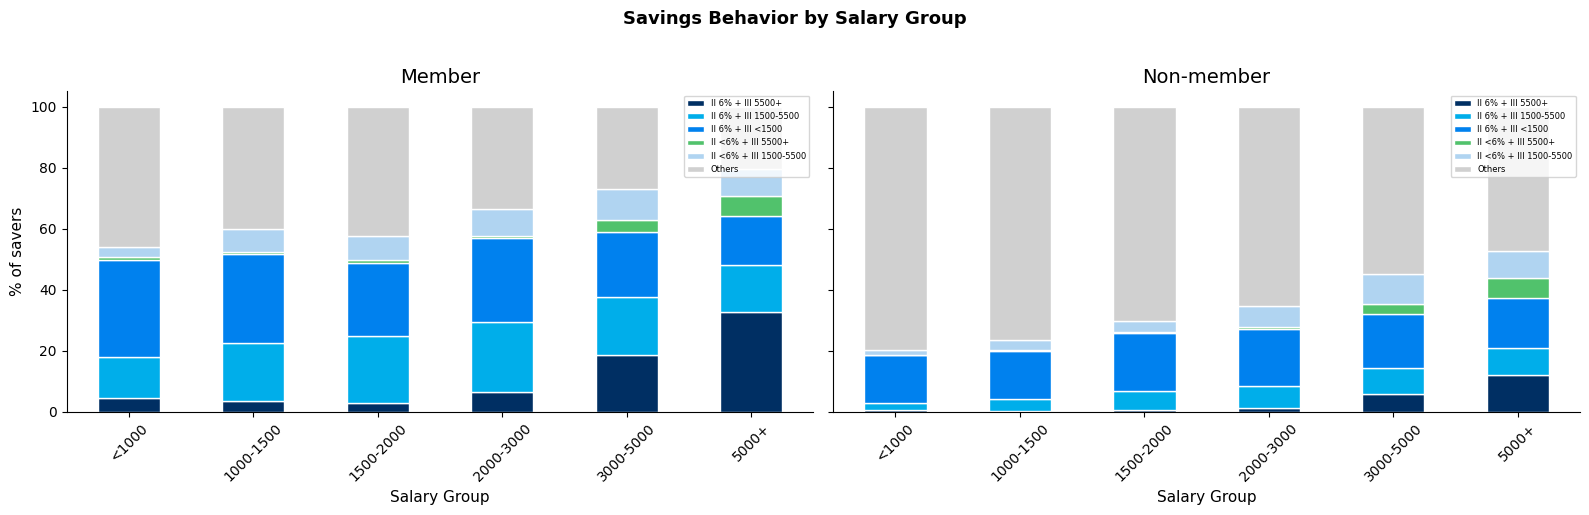

In [20]:
# Savings behavior by salary — faceted by Source
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, source in zip(axes, ['Member', 'Non-member']):
    sub = df[(df['Source'] == source) & df['Latest Salary'].notna()]
    sub_sg = sub.join(sg_dummies.loc[sub.index])
    sg_by_sal = sub_sg.groupby('Salary Group', observed=True)[savings_order].mean() * 100
    sg_by_sal.plot(kind='bar', stacked=True, ax=ax, color=sg_colors, edgecolor='white')
    ax.set_title(f'{source}')
    ax.set_ylabel('% of savers')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=6, loc='upper right')

fig.suptitle('Savings Behavior by Salary Group', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Combined Analysis — Members vs Non-members

In [21]:
# Derived columns for combined analysis
df['Left Tuleva'] = df['Early Withdrawal Date'].notna() | df['Last Transfer Out Date'].notna()
df['Voluntary Rate'] = df['Current Rate'] > 2
df['III Annual Contrib'] = df['Third Pillar Last 12m Contributions Sum']
df['III Savings Rate'] = np.where(
    (df['III Annual Contrib'] > 0) & (df['Latest Salary'] > 0),
    df['III Annual Contrib'] / (df['Latest Salary'] * 12) * 100,
    np.nan
)

# Finer age bins
df['Age 5y'] = pd.cut(df['Age'], bins=[0, 25, 30, 35, 40, 45, 50, 55, 60, 65, 100],
                       labels=['18-25', '26-30', '31-35', '36-40', '41-45', '46-50', '51-55', '56-60', '61-65', '65+'])

# Broader salary tiers
df['Salary Tier'] = pd.cut(df['Latest Salary'], bins=[0, 1500, 2500, 5000, 100000],
                           labels=['<1.5K', '1.5-2.5K', '2.5-5K', '5K+'])

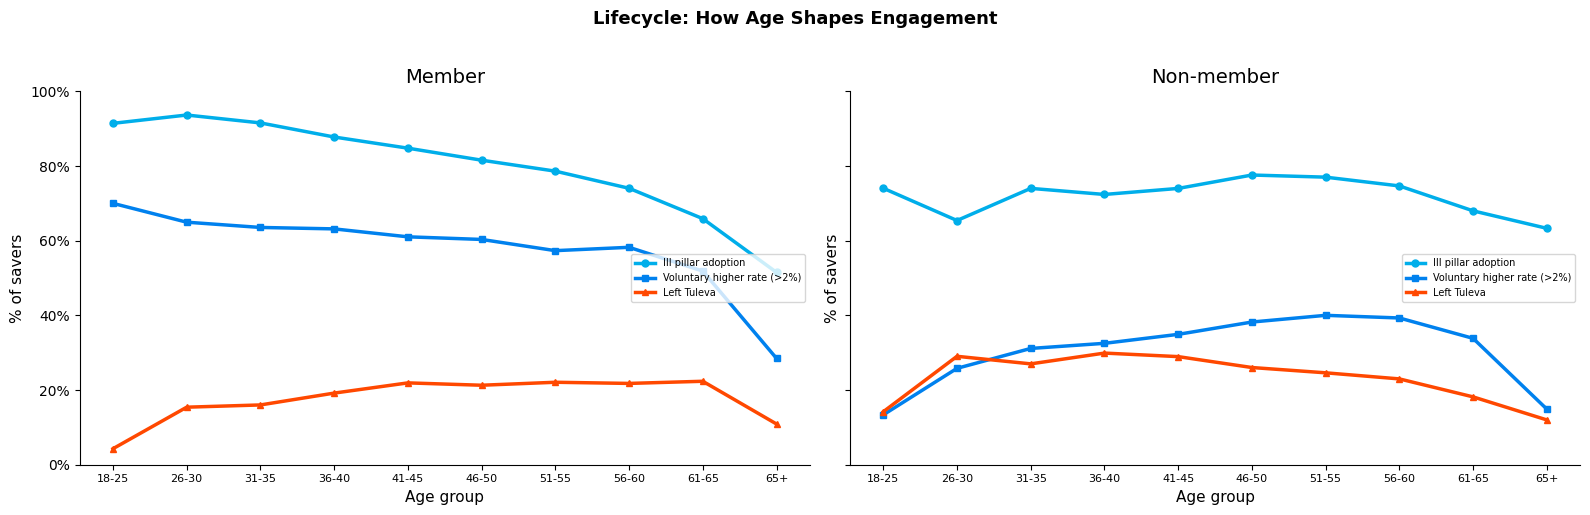

In [22]:
# Lifecycle — Members vs Non-members
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, source in zip(axes, ['Member', 'Non-member']):
    sub = df[df['Source'] == source]
    age_stats = sub.groupby('Age 5y', observed=True).agg(
        iii_adoption=('Has III Pillar', 'mean'),
        voluntary_rate=('Voluntary Rate', 'mean'),
        left_tuleva=('Left Tuleva', 'mean'),
    ).reset_index()

    x = range(len(age_stats))
    ax.plot(x, age_stats['iii_adoption'] * 100, 'o-', color=TULEVA_BLUE, linewidth=2.5, markersize=5, label='III pillar adoption')
    ax.plot(x, age_stats['voluntary_rate'] * 100, 's-', color=TULEVA_MID_BLUE, linewidth=2.5, markersize=5, label='Voluntary higher rate (>2%)')
    ax.plot(x, age_stats['left_tuleva'] * 100, '^-', color=NEGATIVE_COLOR, linewidth=2.5, markersize=5, label='Left Tuleva')

    ax.set_xticks(x)
    ax.set_xticklabels(age_stats['Age 5y'], fontsize=8)
    ax.set_xlabel('Age group')
    ax.set_ylabel('% of savers')
    ax.set_title(f'{source}')
    ax.legend(fontsize=7, loc='center right')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))

fig.suptitle('Lifecycle: How Age Shapes Engagement', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

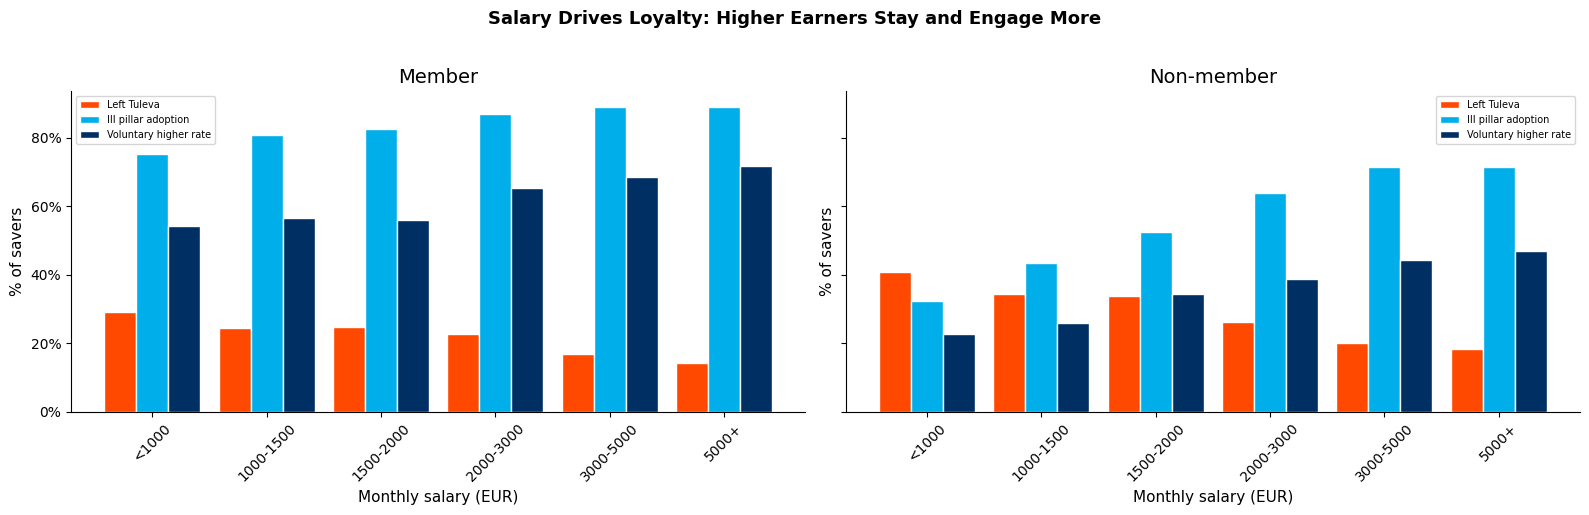

In [23]:
# Salary drives loyalty — Members vs Non-members
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, source in zip(axes, ['Member', 'Non-member']):
    sub = df[(df['Source'] == source) & df['Latest Salary'].notna()]
    sal_stats = sub.groupby('Salary Group', observed=True).agg(
        left_pct=('Left Tuleva', 'mean'),
        iii_adoption=('Has III Pillar', 'mean'),
        voluntary_rate=('Voluntary Rate', 'mean'),
    ).reset_index()

    x = np.arange(len(sal_stats))
    w = 0.28
    ax.bar(x - w, sal_stats['left_pct'] * 100, w, color=NEGATIVE_COLOR, label='Left Tuleva', edgecolor='white')
    ax.bar(x, sal_stats['iii_adoption'] * 100, w, color=TULEVA_BLUE, label='III pillar adoption', edgecolor='white')
    ax.bar(x + w, sal_stats['voluntary_rate'] * 100, w, color=TULEVA_NAVY, label='Voluntary higher rate', edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(sal_stats['Salary Group'], rotation=45)
    ax.set_xlabel('Monthly salary (EUR)')
    ax.set_ylabel('% of savers')
    ax.set_title(f'{source}')
    ax.legend(fontsize=7)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))

fig.suptitle('Salary Drives Loyalty: Higher Earners Stay and Engage More', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

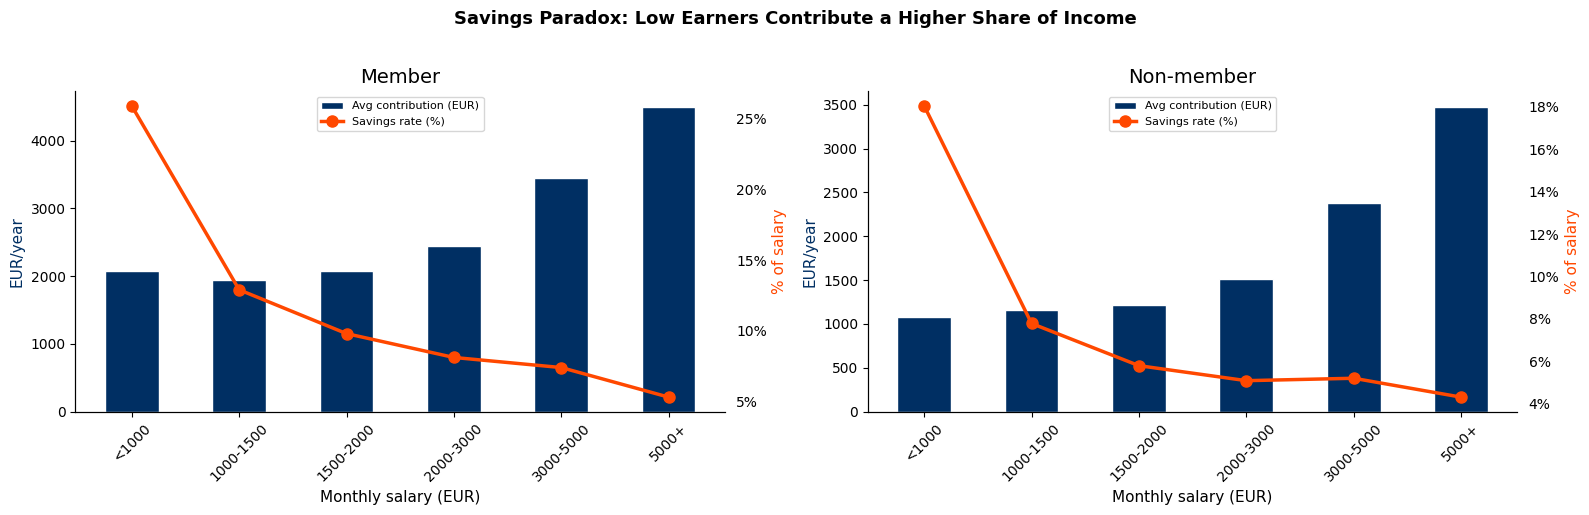

In [24]:
# Savings paradox — Members vs Non-members
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax_left, source in zip(axes, ['Member', 'Non-member']):
    sub = df[(df['Source'] == source) & df['Latest Salary'].notna()]
    sal_savings = sub.groupby('Salary Group', observed=True).agg(
        mean_contrib=('III Annual Contrib', lambda s: s[s > 0].mean() if (s > 0).any() else 0),
        mean_rate=('III Savings Rate', 'mean'),
    ).reset_index()

    ax_right = ax_left.twinx()
    x = np.arange(len(sal_savings))
    ax_left.bar(x, sal_savings['mean_contrib'], 0.5, color=TULEVA_NAVY, edgecolor='white', label='Avg contribution (EUR)', zorder=2)
    ax_right.plot(x, sal_savings['mean_rate'], 'o-', color=NEGATIVE_COLOR, linewidth=2.5, markersize=8, label='Savings rate (%)', zorder=3)

    ax_left.set_xticks(x)
    ax_left.set_xticklabels(sal_savings['Salary Group'], rotation=45)
    ax_left.set_xlabel('Monthly salary (EUR)')
    ax_left.set_ylabel('EUR/year', color=TULEVA_NAVY)
    ax_right.set_ylabel('% of salary', color=NEGATIVE_COLOR)
    ax_right.tick_params(axis='y', length=0, pad=8)
    ax_right.spines['right'].set_visible(False)
    ax_right.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x:.0f}%'))
    ax_left.set_title(f'{source}')

    lines1, labels1 = ax_left.get_legend_handles_labels()
    lines2, labels2 = ax_right.get_legend_handles_labels()
    ax_left.legend(lines1 + lines2, labels1 + labels2, loc='upper center', fontsize=8)

fig.suptitle('Savings Paradox: Low Earners Contribute a Higher Share of Income', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

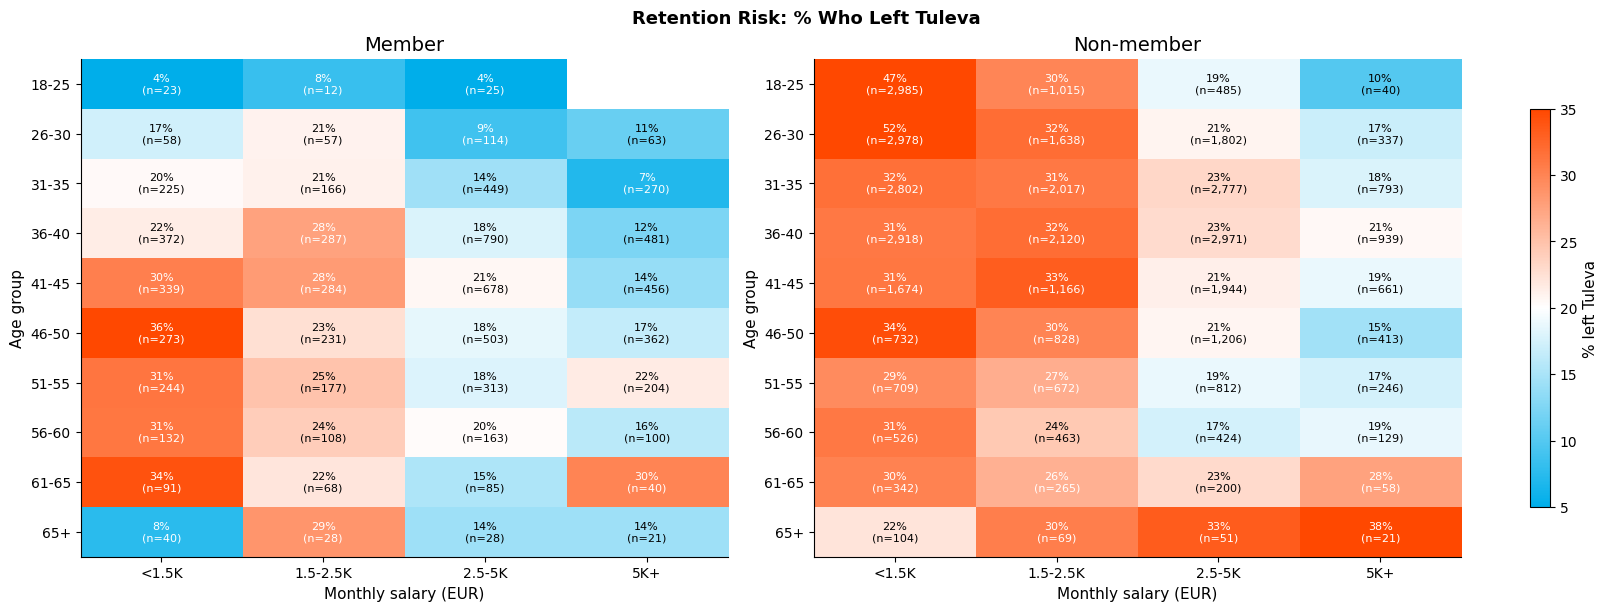

In [25]:
# Retention heatmap — faceted by Source
fig, axes = plt.subplots(1, 2, figsize=(16, 6), layout='constrained')
cmap = mcolors.LinearSegmentedColormap.from_list('tuleva', [TULEVA_BLUE, '#FFFFFF', NEGATIVE_COLOR])

for ax, source in zip(axes, ['Member', 'Non-member']):
    sub = df[(df['Source'] == source) & df['Latest Salary'].notna()]
    cross = sub.groupby(['Age 5y', 'Salary Tier'], observed=True).agg(
        left_pct=('Left Tuleva', 'mean'),
        n=('Age', 'size'),
    )
    heatmap_data = cross['left_pct'].unstack() * 100
    heatmap_n = cross['n'].unstack()

    im = ax.imshow(heatmap_data.values, cmap=cmap, aspect='auto', vmin=5, vmax=35)
    ax.set_xticks(range(len(heatmap_data.columns)))
    ax.set_xticklabels(heatmap_data.columns)
    ax.set_yticks(range(len(heatmap_data.index)))
    ax.set_yticklabels(heatmap_data.index)
    ax.set_xlabel('Monthly salary (EUR)')
    ax.set_ylabel('Age group')
    ax.set_title(f'{source}')

    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            val = heatmap_data.values[i, j]
            n = heatmap_n.values[i, j]
            if not np.isnan(val):
                color = 'white' if val > 25 or val < 10 else 'black'
                ax.text(j, i, f'{val:.0f}%\n(n={n:,.0f})', ha='center', va='center', fontsize=8, color=color)

fig.colorbar(im, ax=axes, shrink=0.8, label='% left Tuleva')
fig.suptitle('Retention Risk: % Who Left Tuleva', fontsize=13, fontweight='bold')
plt.show()

## 8. Personas

Five mutually exclusive segments based on pillar adoption, savings behavior, and engagement — applied equally to members and non-members.

In [26]:
# Assign personas
def assign_persona(row):
    if row['Total AUM'] == 0:
        return 'Gone'
    if row['Has Both Pillars'] and row['Voluntary Rate'] and row['III Annual Contrib'] >= 2400:
        return 'Power Saver'
    if row['Has Both Pillars'] and (row['Voluntary Rate'] or row['III Annual Contrib'] > 0):
        return 'Steady Saver'
    if row['Has Both Pillars']:
        return 'Coaster'
    return 'Single Pillar'

df['Persona'] = df.apply(assign_persona, axis=1)

PERSONA_ORDER = ['Power Saver', 'Steady Saver', 'Coaster', 'Single Pillar', 'Gone']
PERSONA_COLORS = [TULEVA_NAVY, TULEVA_BLUE, TULEVA_MID_BLUE, '#B0D4F1', '#D0D0D0']

# Summary table by Source
rows = []
for source in ['Member', 'Non-member', 'Total']:
    sub_src = df if source == 'Total' else df[df['Source'] == source]
    for p in PERSONA_ORDER:
        sub = sub_src[sub_src['Persona'] == p]
        sal = sub['Latest Salary'].dropna()
        rows.append({
            'Source': source,
            'Persona': p,
            'Savers': len(sub),
            '% of Source': len(sub) / len(sub_src) * 100,
            'AUM (M EUR)': sub['Total AUM'].sum() / 1e6,
            '% of AUM': sub['Total AUM'].sum() / sub_src['Total AUM'].sum() * 100 if sub_src['Total AUM'].sum() > 0 else 0,
            'Median Age': sub['Age'].median(),
            'Mean AUM': sub['Total AUM'].mean(),
            '% Left': sub['Left Tuleva'].mean() * 100,
        })

persona_tbl = pd.DataFrame(rows)
persona_tbl.style.format({
    'Savers': '{:,}',
    '% of Source': '{:.1f}%',
    'AUM (M EUR)': '{:.1f}',
    '% of AUM': '{:.1f}%',
    'Median Age': '{:.0f}',
    'Mean AUM': '{:,.0f}',
    '% Left': '{:.0f}%',
}).hide(axis='index')

Source,Persona,Savers,% of Source,AUM (M EUR),% of AUM,Median Age,Mean AUM,% Left
Member,Power Saver,"2,518",26.3%,221.7,47.0%,42,"88,056",6%
Member,Steady Saver,"3,671",38.3%,173.4,36.7%,42,"47,228",16%
Member,Coaster,758,7.9%,23.8,5.0%,41,"31,418",33%
Member,Single Pillar,"1,777",18.6%,52.9,11.2%,46,"29,754",25%
Member,Gone,849,8.9%,0.0,0.0%,48,0,56%
Non-member,Power Saver,"3,028",3.5%,165.5,17.1%,39,"54,647",7%
Non-member,Steady Saver,"14,749",17.0%,370.9,38.2%,37,"25,147",16%
Non-member,Coaster,"3,970",4.6%,71.8,7.4%,36,"18,078",23%
Non-member,Single Pillar,"54,584",62.7%,362.2,37.3%,36,"6,636",18%
Non-member,Gone,"10,665",12.3%,0.0,0.0%,35,0,80%


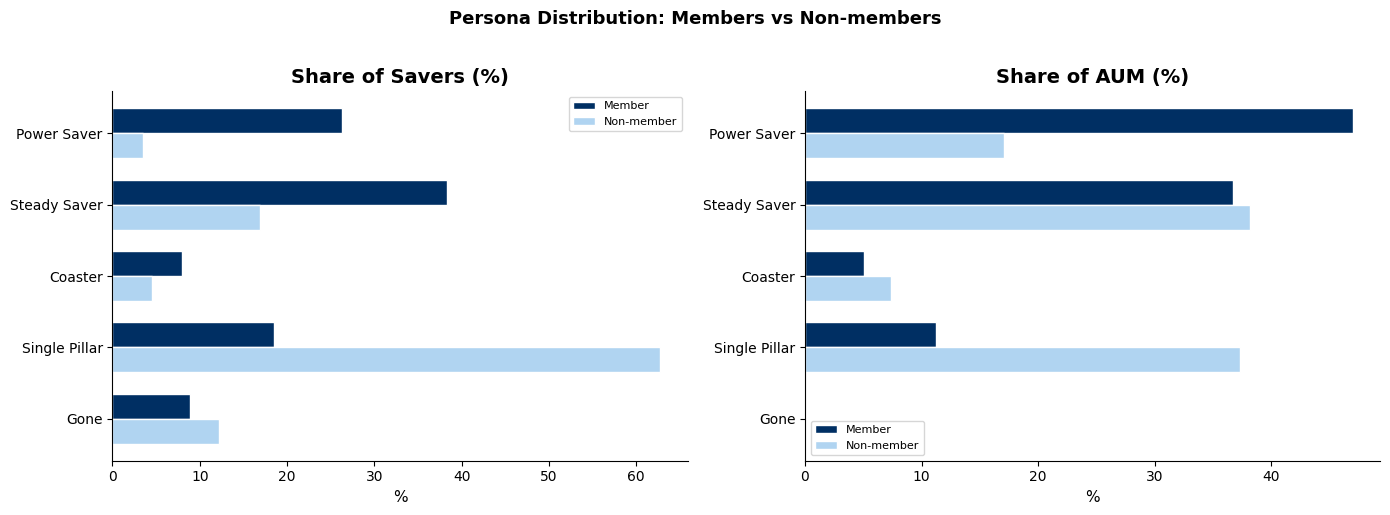

In [27]:
# Persona distribution — Members vs Non-members
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (metric, title, fmt) in zip(axes, [
    ('pct', 'Share of Savers (%)', lambda v, src: f'{v:.0f}%'),
    ('aum_pct', 'Share of AUM (%)', lambda v, src: f'{v:.0f}%'),
]):
    x = np.arange(len(PERSONA_ORDER))
    w = 0.35

    for offset, source, color in [(-w/2, 'Member', MEMBER_COLOR), (w/2, 'Non-member', NONMEMBER_COLOR)]:
        sub_src = df[df['Source'] == source]
        if metric == 'pct':
            vals = [len(sub_src[sub_src['Persona'] == p]) / len(sub_src) * 100 for p in PERSONA_ORDER]
        else:
            total_aum = sub_src['Total AUM'].sum()
            vals = [sub_src[sub_src['Persona'] == p]['Total AUM'].sum() / total_aum * 100 if total_aum > 0 else 0 for p in PERSONA_ORDER]
        ax.barh(x + offset, vals, w, color=color, edgecolor='white', label=source)

    ax.set_yticks(x)
    ax.set_yticklabels(PERSONA_ORDER)
    ax.set_xlabel('%')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.invert_yaxis()

fig.suptitle('Persona Distribution: Members vs Non-members', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

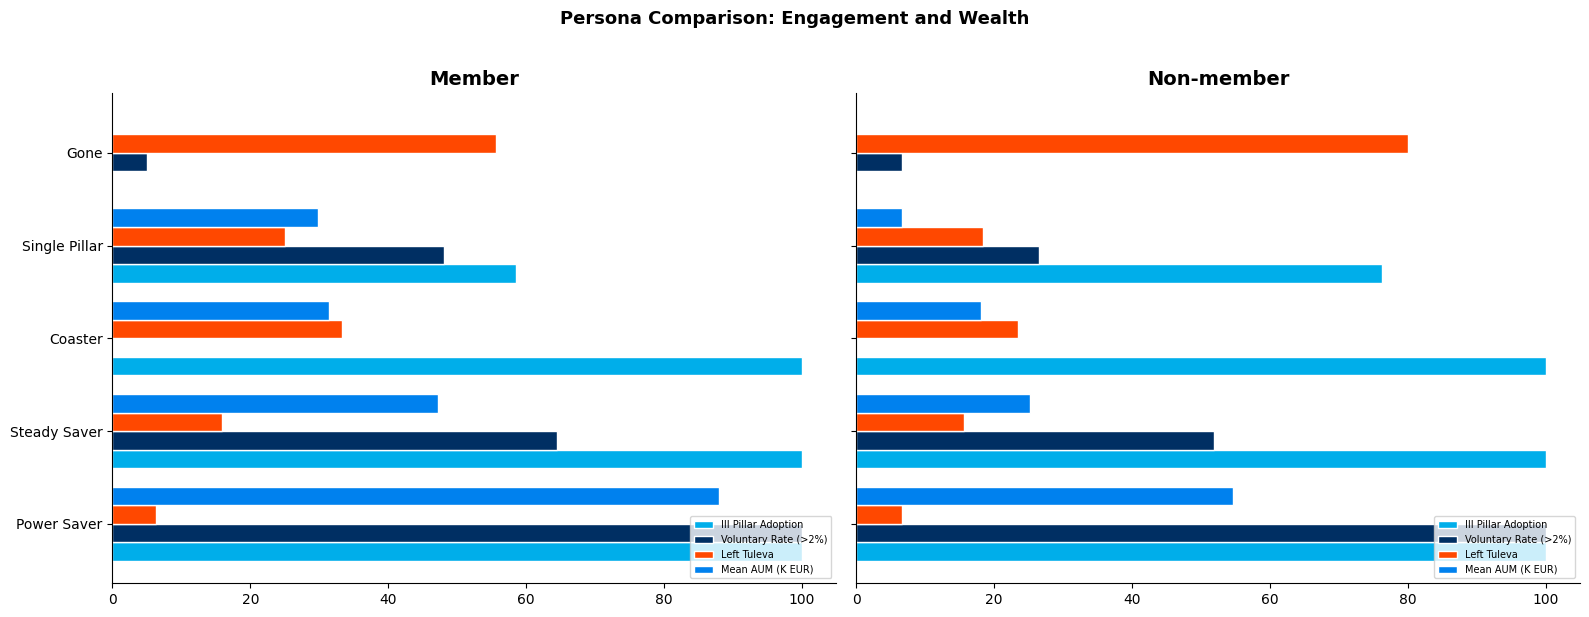

In [28]:
# Persona comparison — key metrics, faceted by Source
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, source in zip(axes, ['Member', 'Non-member']):
    sub_src = df[df['Source'] == source]
    metrics = []
    for p in PERSONA_ORDER:
        sub = sub_src[sub_src['Persona'] == p]
        sal = sub['Latest Salary'].dropna()
        metrics.append({
            'Persona': p,
            'III Pillar Adoption': sub['Has III Pillar'].mean() * 100,
            'Voluntary Rate (>2%)': sub['Voluntary Rate'].mean() * 100,
            'Left Tuleva': sub['Left Tuleva'].mean() * 100,
            'Mean AUM (K EUR)': sub['Total AUM'].mean() / 1000,
        })
    mdf = pd.DataFrame(metrics).set_index('Persona')

    n_cols = len(mdf.columns)
    x = np.arange(len(PERSONA_ORDER))
    w = 0.8 / n_cols

    for j, col in enumerate(mdf.columns):
        vals = mdf[col].loc[PERSONA_ORDER]
        ax.barh(x + j * w - 0.4 + w/2, vals, w, label=col, edgecolor='white',
                color=[TULEVA_BLUE, TULEVA_NAVY, NEGATIVE_COLOR, TULEVA_MID_BLUE][j])

    ax.set_yticks(x)
    ax.set_yticklabels(PERSONA_ORDER)
    ax.set_title(f'{source}', fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.invert_yaxis()

fig.suptitle('Persona Comparison: Engagement and Wealth', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# Persona descriptions — data-driven, split by Source
for source in ['Member', 'Non-member']:
    sub_src = df[df['Source'] == source]
    print(f'=== {source.upper()} PERSONAS ===\n')
    for p in PERSONA_ORDER:
        sub = sub_src[sub_src['Persona'] == p]
        if len(sub) == 0:
            continue
        n = len(sub)
        pct = n / len(sub_src) * 100
        sal = sub['Latest Salary'].dropna()
        median_sal = sal.median() if len(sal) else 0
        median_age = sub['Age'].median()
        mean_aum = sub['Total AUM'].mean()
        aum_share = sub['Total AUM'].sum() / sub_src['Total AUM'].sum() * 100
        left_pct = sub['Left Tuleva'].mean() * 100
        iii_adopt = sub['Has III Pillar'].mean() * 100
        vol_rate = sub['Voluntary Rate'].mean() * 100
        iii_contrib = sub.loc[sub['III Annual Contrib'] > 0, 'III Annual Contrib']
        mean_iii = iii_contrib.mean() if len(iii_contrib) else 0
        gender_top = sub['Gender'].value_counts().idxmax()
        gender_pct = sub['Gender'].value_counts().iloc[0] / len(sub) * 100

        print(f'--- {p.upper()} ({n:,} savers, {pct:.0f}% of {source.lower()}s, {aum_share:.0f}% of AUM) ---')
        print(f'  Typical: {median_age:.0f}-year-old, earns {median_sal:,.0f} EUR/month, {mean_aum:,.0f} EUR avg AUM')
        print(f'  Gender:  {gender_pct:.0f}% {gender_top}')
        print(f'  III pillar adoption: {iii_adopt:.0f}%, voluntary higher rate: {vol_rate:.0f}%', end='')
        if mean_iii > 0:
            print(f', avg III contrib: {mean_iii:,.0f} EUR/year')
        else:
            print()
        print(f'  Left Tuleva: {left_pct:.0f}%')
        print()

=== MEMBER PERSONAS ===

--- POWER SAVER (2,518 savers, 26% of members, 47% of AUM) ---
  Typical: 42-year-old, earns 4,232 EUR/month, 88,056 EUR avg AUM
  Gender:  61% M
  III pillar adoption: 100%, voluntary higher rate: 100%, avg III contrib: 5,127 EUR/year
  Left Tuleva: 6%

--- STEADY SAVER (3,671 savers, 38% of members, 37% of AUM) ---
  Typical: 42-year-old, earns 2,802 EUR/month, 47,228 EUR avg AUM
  Gender:  56% M
  III pillar adoption: 100%, voluntary higher rate: 64%, avg III contrib: 1,600 EUR/year
  Left Tuleva: 16%

--- COASTER (758 savers, 8% of members, 5% of AUM) ---
  Typical: 41-year-old, earns 2,392 EUR/month, 31,418 EUR avg AUM
  Gender:  63% M
  III pillar adoption: 100%, voluntary higher rate: 0%
  Left Tuleva: 33%

--- SINGLE PILLAR (1,777 savers, 19% of members, 11% of AUM) ---
  Typical: 46-year-old, earns 2,840 EUR/month, 29,754 EUR avg AUM
  Gender:  62% M
  III pillar adoption: 58%, voluntary higher rate: 48%, avg III contrib: 3,063 EUR/year
  Left Tuleva: 